# Exploratory Data Analysis

In [174]:
# NLP Analysis:
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

# Data exploration:
import pandas as pd

# Data Visualization:
import matplotlib.pyplot as plt

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/its30na/nltk_data...


In [80]:
df = pd.read_csv('../data/raw/berlin_reviews_clean.csv')
df

,title,url,cuisines,reviews,star rating,page number,data offset,restaurant,dates,dates_parsed,earliest_date,latest_date,review_count,review_period_days,language,clean_reviews
0,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",The atmosphere is very classy yet cozy. The ow...,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,atmosphere classy yet cozy owner gracious repr...
1,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",Ricardo took excellent are of us last night. H...,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,ricardo took excellent us last night picked wi...
2,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",Best copanata I ever had !! Every dish we orde...,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,best copanata ever every dish ordered cooked p...
3,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",This is now our favorite restaurant in Berlin....,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,favorite restaurant berlin loved everything am...
4,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian","Absolutely delicious food, great host, great w...",4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,absolutely delicious food great host great win...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143613,5637. Cancun,https://www.tripadvisor.in/Restaurant_Review-g...,"Mexican, Latin",If a famine ever breaks out and cacun is the o...,2.5 of 5 bubbles,187,5610,5637,"['20 October 2023', '21 September 2023', '18 S...","[Timestamp('2023-10-20 00:00:00'), Timestamp('...",2012-07-23,2023-10-20,197,4106.0,en,famine ever breaks cacun restaurant left earth...
143614,5637. Cancun,https://www.tripadvisor.in/Restaurant_Review-g...,"Mexican, Latin",It was the first time we had Mexican food. We ...,2.5 of 5 bubbles,187,5610,5637,"['20 October 2023', '21 September 2023', '18 S...","[Timestamp('2023-10-20 00:00:00'), Timestamp('...",2012-07-23,2023-10-20,197,4106.0,en,first time mexican food ordered meal combinati...
143615,5639. Fame Burger,https://www.tripadvisor.in/Restaurant_Review-g...,"American, Grill","Fast fresh and big we will order again, we ord...",2.0 of 5 bubbles,187,5610,5639,['16 May 2021'],[Timestamp('2021-05-16 00:00:00')],2021-05-16,2021-05-16,1,0.0,en,fast fresh big order order one bowl one vegan ...
143616,5640. BackWerk,https://www.tripadvisor.in/Restaurant_Review-g...,NaN,Very unfriendly personnel. You cant expect muc...,1.0 of 5 bubbles,187,5610,5640,['19 October 2021'],[Timestamp('2021-10-19 00:00:00')],2021-10-19,2021-10-19,1,0.0,en,unfriendly personnel cant expect much train st...


In [73]:
df.shape

(143618, 16)

In [74]:
# Looking at the star ratings, we have more than 94% of the reviews with review scores > 3.0
# That means that about maximum 6% of the reviews are either critical or have a critic aspect in them, which could be good to know.
# Meanwhile ~21% of reviews are less-than-strongly-positive, being the ones with less than 4 stars.
round(df["star rating"].value_counts(normalize = True),6)

star rating
4.0 of 5 bubbles    0.410564
4.5 of 5 bubbles    0.359254
3.5 of 5 bubbles    0.157941
3.0 of 5 bubbles    0.043922
5.0 of 5 bubbles    0.023521
2.5 of 5 bubbles    0.004630
2.0 of 5 bubbles    0.000077
1.0 of 5 bubbles    0.000077
1.5 of 5 bubbles    0.000014
Name: proportion, dtype: float64

The distribution of star ratings reveals a strong positive skew in the dataset. 

Approximately 95% of reviews have ratings above 3.0, while only about 5% fall at or below 3 stars.
The majority of reviews are concentrated in the 4.0 (41.1%) and 4.5 (35.9%) categories, indicating generally high customer satisfaction. 
Reviews below 4.0 stars account for roughly 21% of the data, suggesting a smaller proportion of moderately positive or mixed experiences. 

However, it is important to note that lower ratings do not fully capture negative sentiment, as even highly rated reviews may contain critical feedback. This imbalance toward positive ratings should be considered in downstream tasks such as sentiment analysis or predictive modeling, as it may bias models toward overpredicting positive outcomes.

### My Verdict: Three possible routes for analyzing the cleaned dataset further:
1. Aspect-Based Sentiment Analysis
2. Sentiment classification
3. Restaurant ranking / insights

In [131]:
# Group reviews per Restaurant:
restaurant_texts = df.groupby(
    ["restaurant", "title"]
)["clean_reviews"].apply(lambda x: " ".join(x.dropna().astype(str))).reset_index()

In [132]:
restaurant_texts = restaurant_texts.rename(columns={
    "clean_reviews": "all_reviews"
})

In [133]:
restaurant_texts

,restaurant,title,all_reviews
0,1,1. Focaccino,atmosphere classy yet cozy owner gracious repr...
1,2,2. Cafe Couscous - Vege,best wraps berlin period suggest getting cousc...
2,3,3. Hackethals,found place tripadvisor wanted give try locate...
3,4,4. Restaurant Buschbeck's,wife coeliac research places could eat going b...
4,5,5. 100 Gramm Bar,place amaizing loved vibe music staff drinks c...
...,...,...,...
4380,5636,5636. PizzaBulls Deutschland,worst expereince ever customer service poor fo...
4381,5637,5637. Cancun,also good food vegetarians pay cash keep money...
4382,5639,5639. Fame Burger,fast fresh big order order one bowl one vegan ...
4383,5640,5640. BackWerk,unfriendly personnel cant expect much train st...


## 1. Aspect-Based Sentiment Analysis

In [175]:
# Getting TF Idf
ectorizer = TfidfVectorizer(
    max_features=5000,
    max_df=0.8,   # remove very common words
    min_df=5      # remove rare words
)
X = vectorizer.fit_transform(restaurant_texts["all_reviews"])

In [176]:
feature_names = vectorizer.get_feature_names_out()

In [177]:
feature_names

array(['ability', 'able', 'abroad', ..., 'zucchini', 'zum', 'zur'],
      shape=(5000,), dtype=object)

In [178]:
import numpy as np

def get_top_words(row, top_n=10):
    row_array = row.toarray().flatten()
    top_indices = np.argsort(row_array)[-top_n:][::-1]
    return [feature_names[i] for i in top_indices]

top_words_per_restaurant = [
    get_top_words(X[i], 10) for i in range(X.shape[0])
]

In [179]:
results = pd.DataFrame({
    "title": restaurant_texts.title,
    "restaurant": restaurant_texts.index+1,
    "top_words": top_words_per_restaurant
})

In [180]:
results["top_words"] = results["top_words"].apply(lambda x: ", ".join(x))

In [181]:
results

,title,restaurant,top_words
0,1. Focaccino,1,"italian, food, owner, restaurant, sicilian, pa..."
1,2. Cafe Couscous - Vege,2,"couscous, wraps, owner, falafel, fresh, hallou..."
2,3. Hackethals,3,"hackethals, food, german, beer, menu, restaura..."
3,4. Restaurant Buschbeck's,4,"food, restaurant, service, delicious, berlin, ..."
4,5. 100 Gramm Bar,5,"cocktails, drinks, bar, good, great, cool, atm..."
...,...,...,...
4380,5636. PizzaBulls Deutschland,4381,"delivery, pizza, mexico, worst, hade, fly, nea..."
4381,5637. Cancun,4382,"mexican, food, service, waiter, us, good, rest..."
4382,5639. Fame Burger,4383,"one, order, bowl, burger, favorite, vegan, fas..."
4383,5640. BackWerk,4384,"select, cant, personnel, train, unfriendly, st..."


In [193]:
results.to_csv("../data/raw/berlin_reviews_topwords.csv", index=False)

AttributeError: 'list' object has no attribute 'to_csv'

**Now i can say:**

“Restaurant 1 is mostely associated respectively with italian, food, owner, restaurant, sicilian, pasta...”

“Restaurant 2 is mostely associated respectively with couscous, wraps, owner, falafel, fresh, halloummi...”

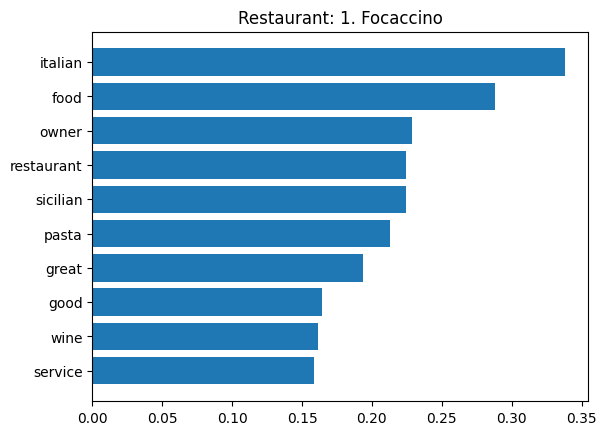

In [182]:
row = X[0].toarray().flatten()
top_indices = np.argsort(row)[-10:]

plt.barh(
    [feature_names[i] for i in top_indices],
    row[top_indices]
)
plt.title("Restaurant: " + restaurant_texts.title[0])
plt.show()

### I will now use VADER, a simple tool for this purpose:

In [183]:
sia = SentimentIntensityAnalyzer()

df["sentiment_score"] = df["reviews"].apply(lambda x: sia.polarity_scores(x)["compound"])

In [186]:
df.head()

,title,url,cuisines,reviews,star rating,page number,data offset,restaurant,dates,dates_parsed,earliest_date,latest_date,review_count,review_period_days,language,clean_reviews,sentiment_score
0,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",The atmosphere is very classy yet cozy. The ow...,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,atmosphere classy yet cozy owner gracious repr...,0.9693
1,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",Ricardo took excellent are of us last night. H...,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,ricardo took excellent us last night picked wi...,0.9656
2,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",Best copanata I ever had !! Every dish we orde...,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,best copanata ever every dish ordered cooked p...,0.9706
3,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian",This is now our favorite restaurant in Berlin....,4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,favorite restaurant berlin loved everything am...,0.9708
4,1. Focaccino,https://www.tripadvisor.in/Restaurant_Review-g...,"Italian, Sicilian","Absolutely delicious food, great host, great w...",4.5 of 5 bubbles,0,0,1,"['13 November 2023', '23 September 2023', '28 ...","[Timestamp('2023-11-13 00:00:00'), Timestamp('...",2011-08-19,2023-11-13,202,4469.0,en,absolutely delicious food great host great win...,0.9698


We go back to review-level data, not aggregated text and revectorize:

In [187]:
vectorizer = TfidfVectorizer(max_features=5000, max_df=0.8, min_df=5)
X_reviews = vectorizer.fit_transform(df["clean_reviews"])

feature_names = vectorizer.get_feature_names_out()

In [188]:
feature_names

array(['ability', 'able', 'abroad', ..., 'zucchini', 'zum', 'zur'],
      shape=(5000,), dtype=object)

In [189]:
word_sentiment = {}

for i, word in enumerate(feature_names):
    scores = X_reviews[:, i].toarray().flatten()
    
    if scores.sum() == 0:
        continue
    
    weighted_sentiment = (scores * df["sentiment_score"]).sum() / scores.sum()
    word_sentiment[word] = weighted_sentiment

In [190]:
word_sentiment

{'ability': np.float64(0.6954687127750557),
 'able': np.float64(0.6196956119743152),
 'abroad': np.float64(0.5552196492825465),
 'abrupt': np.float64(0.14761214893030086),
 'absolute': np.float64(0.6450663296584892),
 'absolutely': np.float64(0.7641623835154518),
 'abundant': np.float64(0.7469497045297038),
 'accent': np.float64(0.36808239363179424),
 'accept': np.float64(0.3688269648119234),
 'acceptable': np.float64(0.46942270939754155),
 'accepted': np.float64(0.6063848869096313),
 'access': np.float64(0.7039707453382696),
 'accessible': np.float64(0.7332958122323643),
 'accident': np.float64(0.6147339552996745),
 'accidentally': np.float64(0.5312568410727926),
 'accommodate': np.float64(0.6828896083193671),
 'accommodated': np.float64(0.7232823043944845),
 'accommodating': np.float64(0.7985519571634698),
 'accommodation': np.float64(0.7045573751052069),
 'accomodating': np.float64(0.8162139304009857),
 'accompanied': np.float64(0.7729065175026311),
 'accompaniment': np.float64(0.78

In [191]:
sorted_words = sorted(word_sentiment.items(), key=lambda x: x[1])

negative_words = sorted_words[:20]
positive_words = sorted_words[-20:]

In [192]:
results = []

for rest_id, group in df.groupby("restaurant"):
    
    X_local = vectorizer.transform(group["clean_reviews"])
    sentiments = group["sentiment_score"].values
    
    word_scores = {}
    
    for i, word in enumerate(feature_names):
        scores = X_local[:, i].toarray().flatten()
        
        if scores.sum() == 0:
            continue
        
        weighted = (scores * sentiments).sum() / scores.sum()
        word_scores[word] = weighted
    
    sorted_local = sorted(word_scores.items(), key=lambda x: x[1])
    
    results.append({
        "restaurant": rest_id,
        "top_negative": [w for w, _ in sorted_local[:10]],
        "top_positive": [w for w, _ in sorted_local[-10:]]
    })

In [194]:
results_df = pd.DataFrame(results).merge(
    df[["restaurant", "title"]].drop_duplicates(),
    on="restaurant"
)

results_df["top_negative"] = results_df["top_negative"].apply(", ".join)
results_df["top_positive"] = results_df["top_positive"].apply(", ".join)

results_df.to_csv("../data/raw/berlin_reviews_top_posneg.csv", index=False)

In [195]:
results_df

,restaurant,top_negative,top_positive,title
0,1,"bad, disaster, forever, stressed, throw, drink...","tradition, christmas, dinners, famous, months,...",1. Focaccino
1,2,"available, varied, walking, disappointed, smoo...","although, takeaway, outstanding, potato, type,...",2. Cafe Couscous - Vege
2,3,"alongside, insane, miserable, presentation, re...","comforting, eclectic, justice, excellently, su...",3. Hackethals
3,4,"mins, platz, potsdamer, uber, ca, email, marti...","glad, entry, hope, color, courtesy, everyone, ...",4. Restaurant Buschbeck's
4,5,"alcohol, else, god, hoping, knows, left, met, ...","style, times, clear, european, excelent, calle...",5. 100 Gramm Bar
...,...,...,...,...
4380,5636,"also, anything, call, get, hade, high, knew, r...","near, big, fast, food, stayed, thanks, took, c...",5636. PizzaBulls Deutschland
4381,5637,"generally, male, attended, passing, credit, gr...","generous, depth, business, row, covers, probab...",5637. Cancun
4382,5639,"big, bowl, burger, fast, favorite, fresh, one,...","big, bowl, burger, fast, favorite, fresh, one,...",5639. Fame Burger
4383,5640,"train, better, bit, cant, expect, maybe, much,...","cant, expect, maybe, much, people, personnel, ...",5640. BackWerk
